# Modelado predictivo — Supervivencia a 5 años

**TFM:** Sistema de Apoyo a la Decisión Clínica en Oncología Pediátrica  
**Autor:** Alonso Castañón González  
**Dataset:** SEER Research Data — Osteosarcoma y Sarcoma de Ewing pediátrico (2000–2023)

**Objetivo de este notebook:** Entrenar y comparar modelos de clasificación binaria para predecir la supervivencia a 5 años,
partiendo de las conclusiones documentadas en `02_EDA.ipynb` (Sección 9). El modelo final se interpreta mediante SHAP.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix, make_scorer, accuracy_score, f1_score, recall_score, precision_score, fbeta_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap
import pickle
import os
import json

SEED = 2026
np.random.seed(SEED)

print("Entorno configurado correctamente")

Entorno configurado correctamente


## 1) Carga del dataset limpio y verificación

Se carga `seer_osteosarcoma_ewing_clean.parquet`, salida final de `01_limpieza.ipynb`, el mismo archivo usado en `02_EDA.ipynb`. Se verifica que el shape y los tipos de dato coinciden con lo documentado, para confirmar que se parte exactamente del mismo dataset.

In [2]:
DATA_PATH = '../data/seer_osteosarcoma_ewing_clean.parquet'
df = pd.read_parquet(DATA_PATH)

print(f"Shape: {df.shape}")

print("\n---- TIPOS DE DATOS ----")
print(df.dtypes)

print("\n---- PORCENTAJE DE VALORES MISSING POR COLUMNA ----")
missing_pct = (df.isnull().mean() * 100).round(1)
print(missing_pct[missing_pct > 0])

df.head(5)

Shape: (4915, 15)

---- TIPOS DE DATOS ----
age_group               category
sex                     category
year_diagnosis             int64
tumor_type              category
primary_site            category
stage                   category
tumor_size_cs            float64
surgery_code            category
radiation               category
chemotherapy            category
survival_months            int64
survival_months_flag    category
cause_specific_death    category
vital_status            category
target                     int64
dtype: object

---- PORCENTAJE DE VALORES MISSING POR COLUMNA ----
stage            19.2
tumor_size_cs    61.1
surgery_code      4.3
dtype: float64


,age_group,sex,year_diagnosis,tumor_type,primary_site,stage,tumor_size_cs,surgery_code,radiation,chemotherapy,survival_months,survival_months_flag,cause_specific_death,vital_status,target
0,05-09 years,Female,2004,Ewing sarcoma,Upper limb bones,Regional by direct extension only,64.0,Partial resection,Radiation,Yes,239,complete,Alive / Other cause,Alive,0
1,15-19 years,Male,2001,Ewing sarcoma,Trunk / ribs / sternum,NaN,NaN,Radical resection,No radiation,Yes,275,complete,Alive / Other cause,Alive,0
2,10-14 years,Female,2001,Ewing sarcoma,Pelvis / hip,NaN,NaN,No surgery,Radiation,Yes,119,complete,Dead (cancer),Dead,0
3,10-14 years,Female,2001,Osteosarcoma NOS,Lower limb bones,NaN,NaN,Radical resection,No radiation,Yes,274,complete,Alive / Other cause,Alive,0
4,15-19 years,Female,2000,Chondroblastic osteosarcoma,Pelvis / hip,NaN,NaN,No surgery,Radiation,Yes,23,complete,Dead (cancer),Dead,1


## 2) Eliminación de duplicados exactos

Como se comentó en la Sección 4 del notebook `02_EDA.ipynb`, se detectaron 74 filas duplicadas exactas concentradas en el missing de `tumor_size_cs`. Dadas las razones en dicha sección, estas filas duplicadas se eliminan antes del `train_test_split`, para evitar que una misma observación acabe repartida entre train y test y cause *data leakage*. Si eso ocurriera, el modelo podría aprender que hacer con esa fila en vez de generalizar, afectando a las métricas resultantes en el test, las cuales se inflarían artificialmente.

In [3]:
n_duplicados = df.duplicated().sum()
print(f"Duplicados exactos detectados: {n_duplicados}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Shape tras eliminar duplicados: {df.shape}")

Duplicados exactos detectados: 74
Shape tras eliminar duplicados: (4841, 15)


## 3) Agrupación de categorías minoritarias

Tres agrupaciones acordadas tras el EDA:

- **`tumor_type`**: se mantienen `Ewing sarcoma` y `Osteosarcoma NOS` ya que concentran la gran mayoría de casos y se agrupan los 7 subtipos menos comunes de osteosarcoma en `Osteosarcoma (other subtypes)`.
- **`stage`**: se agrupan las 3 categorías de afectación regional (`Regional by direct extension only`, `Regional lymph nodes involved only`, `Regional by both direct extension and lymph node involvement`) en un único nivel debido a al número de muestras y las curvas KM inestables vistas en la Sección 7. Quedan 3 niveles ordinales (`Localized < Regional < Distant`), coherente con el "Summary Stage" estándar de SEER.
- **`primary_site`**: se toma la decisión de mantenerla sin agrupar. Aunque `CNS/meninges` es la categoría más pequeña, en la Sección 5 del EDA se identifica precisamente `Pelvis/hip` y `CNS/meninges` como las dos localizaciones con peor pronóstico. Fusionarla con `Other/NOS` afectaría a esa información en vez de limpiar ruido. Lo único a considerar es que el tamaño muestral bajo afecta a la *estabilidad del coeficiente* en la Regresión Logística, uno de los modelos a probar, aunque no a la capacidad predictiva de Random Forest o XGBoost, que toleran bien categorías pequeñas. Se observará en SHAP si `CNS/meninges` muestra una contribución inestable y si es así se reconsiderará la agrupación.


In [4]:
# tumor_type
osteo_other = [
    'Chondroblastic osteosarcoma',
    'Telangiectatic osteosarcoma',
    'Central osteosarcoma',
    'Fibroblastic osteosarcoma',
    'Small cell osteosarcoma',
    'Intraosseous well differentiated osteosarcoma',
    'Osteosarcoma in Paget disease',
]

df['tumor_type'] = df['tumor_type'].astype(str).replace(
    {new: 'Osteosarcoma (other subtypes)' for new in osteo_other}
)
df['tumor_type'] = pd.Categorical(df['tumor_type'])

# stage
stage_map = {
    'Localized only': 'Localized',
    'Regional by direct extension only': 'Regional',
    'Regional lymph nodes involved only': 'Regional',
    'Regional by both direct extension and lymph node involvement': 'Regional',
    'Distant site(s)/node(s) involved': 'Distant',
}

df['stage'] = df['stage'].astype(str).map(stage_map)

stage_order = ['Localized', 'Regional', 'Distant']
df['stage'] = pd.Categorical(df['stage'], categories=stage_order, ordered=True)

print("---- tumor_type ----")
print(df['tumor_type'].value_counts())
print("\n---- stage ----")
print(df['stage'].value_counts(dropna=False).sort_index())

---- tumor_type ----
tumor_type
Ewing sarcoma                    2117
Osteosarcoma NOS                 1995
Osteosarcoma (other subtypes)     729
Name: count, dtype: int64

---- stage ----
stage
Localized    1360
Regional     1430
Distant      1131
NaN           920
Name: count, dtype: int64


## 4) Definición de X e y - división en train/test

Se define el conjunto de features excluyendo las variables de leakage (`survival_months`, `survival_months_flag`, `cause_specific_death`, `vital_status`) ya identificadas en
`01_limpieza.ipynb`. Se realiza un único `train_test_split` estratificado por `target`, común a los 4 modelos. `tumor_size_cs` se excluye como predictor principal, tal
como se decidió en el EDA (61.1% de missing estructural fuera de 2004-2015).

In [5]:
# Mismas listas que en el 02_EDA.ipynb pero aquí ya se incluye survival_months porque target depende directamente de ella
num_vars = ['year_diagnosis', 'tumor_size_cs', 'survival_months']
cat_vars = ['age_group', 'sex', 'tumor_type', 'primary_site', 'stage', 'surgery_code', 'radiation', 'chemotherapy']
target_var = 'target'

leakage_vars = ['survival_months', 'survival_months_flag', 'cause_specific_death', 'vital_status']
excluded_vars = ['tumor_size_cs'] + leakage_vars

feature_cols = [c for c in num_vars + cat_vars if c not in excluded_vars]
cat_model_vars = [c for c in cat_vars if c in feature_cols]
num_model_vars = [c for c in num_vars if c in feature_cols]
print("Features incluidas:", feature_cols)

X = df[feature_cols]
y = df[target_var]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Proporción target en train: {y_train.mean():.3f}")
print(f"Proporción target en test: {y_test.mean():.3f}")

Features incluidas: ['year_diagnosis', 'age_group', 'sex', 'tumor_type', 'primary_site', 'stage', 'surgery_code', 'radiation', 'chemotherapy']

Train: (3872, 9), Test: (969, 9)
Proporción target en train: 0.288
Proporción target en test: 0.288


## 5) Preprocesado por modelo

Cada modelo requiere un caso o `ColumnTransformer` distinto: 
- Dummy no necesita preprocesado. 
- Regresión Logística y Random Forest requieren imputación de `stage`/`surgery_code` (categoría explícita `"Unknown"` para no inventar información en la variable más predictiva) y codificación one-hot.
- Regresión Logística además necesita escalado de `year_diagnosis`. 
- XGBoost usa `NaN` y codificación categórica nativa, no es necesario imputar ni escalar.

Todo el preprocesado se define dentro de un `Pipeline`, de este modo así se recalcula en cada fold de la validación cruzada, y nunca sobre todo el conjunto train antes de hacer la división en folds.

In [6]:
# Preprocesado Regresión Logística
preprocessor_lr = ColumnTransformer(transformers=[
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_model_vars),
    ('num', StandardScaler(), num_model_vars)
])

# Preprocesado RF
preprocessor_rf = ColumnTransformer(transformers=[
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_model_vars),
    ('num', 'passthrough', num_model_vars)
])

### Preparación específica para XGBoost

Debido a lo comentado, XGBoost no usa `ColumnTransformer` con one-hot, ya que basta con que las columnas categóricas tengan dtype `category` de pandas y activar `enable_categorical=True` al instanciar el modelo (Sección 6). Los `NaN` se dejan sin imputar.

## 6) Modelos

Se entrenan y comparan cuatro modelos, cada uno con un propósito concreto en la narrativa del trabajo:

- **Dummy Classifier**: como su nombre indica, es un *clasificador tonto*, y sirve como referencia mínima ya que predice según la distribución de `target` sin usar ninguna feature. Cualquier modelo real debe superarlo claramente.
- **Regresión Logística**: baseline clásico, con coeficientes (odds ratios) fácilmente explicables. Sirve como referencia a cuánto aporta después la no linealidad de los modelos de árboles.
- **Random Forest**: baseline de ensemble. Se prescinde de un árbol de decisión individual, ya que un solo árbol es inestable y propenso al sobreajuste, y con este tamaño de dataset un RF lo supera casi sin excepción.
- **XGBoost**: en principio, modelo final del trabajo. Maneja de forma nativa los valores ausentes y las variables categóricas de alta cardinalidad. Es compatible con SHAP para la interpretabilidad clínica que requiere la capa predictiva del sistema.

Cada modelo, salvo Dummy obviamente, se ajusta mediante un `GridSearchCV` con `StratifiedKFold(5)`, optimizando la métrica PR-AUC (Precision-Recall Area Under the Curve) con `scoring='average_precision'` en vez de accuracy, F1-Score o ROC-AUC, dado el desbalanceo de clases y el coste clínico de un falso negativo frente a un falso positivo. 

Para cada modelo se analizarán las siguientes métricas sobre el conjunto de test:

- **PR-AUC** (criterio principal): métrica basada en el área bajo la curva Precision-Recall, mide la capacidad de distinguir la clase minoritaria en todo el rango de umbrales, sin verse afectada por el número de negativos como puede ocurrir con ROC-AUC en datasets desbalanceados.
- **ROC-AUC** (referencia): se reporta igualmente por ser la métrica más habitual en estos estudios y así facilitar la comparación.
- **Precision, recall y F1**: referencia inicial. Según los resultados obtenidos se puede probar el rendimiento que puede ofrecer FBeta-Score dándole más importancia al recall.
- **Matriz de confusión**: para visualizar directamente el volumen de falsos negativos, la categoría de mayor coste clínico en este problema.

Antes de comenzar con los modelos, se definen una serie de necesidades comunes entre ellos que sirven de ayuda para la realización del trabajo. En concreto, el esquema de validación cruzada (mismas particiones para los tres, para que sean comparables entre sí), el diccionario de métricas para `cross_validate`, una función para mostrar la
matriz de confusión, y un diccionario donde se irán guardando los resultados de cada modelo de cara a compararlos.

In [7]:
# Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Métricas
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1': make_scorer(f1_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'precision': make_scorer(precision_score, zero_division=0),
}

# Función para la matriz de confusión
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index=[0, 1], columns=[0, 1])
    sns.heatmap(df_cm, annot=True, cmap="Blues", fmt='d', cbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.ylabel("Clase verdadera")
    plt.xlabel("Clase predicha")
    plt.show()

# Diccionario de resultados
resultados_modelos = {}

### 6.1) Dummy Classifier (base mínima)

Se entrena un `DummyClassifier` con `strategy='stratified'`, que predice, como se explicó, respetando la proporción observada de `target` (28.8%). En este caso no se aplica `GridSearchCV` al no tener hiperparámetros que ajustar.

              precision    recall  f1-score   support

           0      0.721     0.720     0.721       690
           1      0.311     0.312     0.311       279

    accuracy                          0.603       969
   macro avg      0.516     0.516     0.516       969
weighted avg      0.603     0.603     0.603       969



ROC-AUC: 0.516
PR-AUC:  0.295


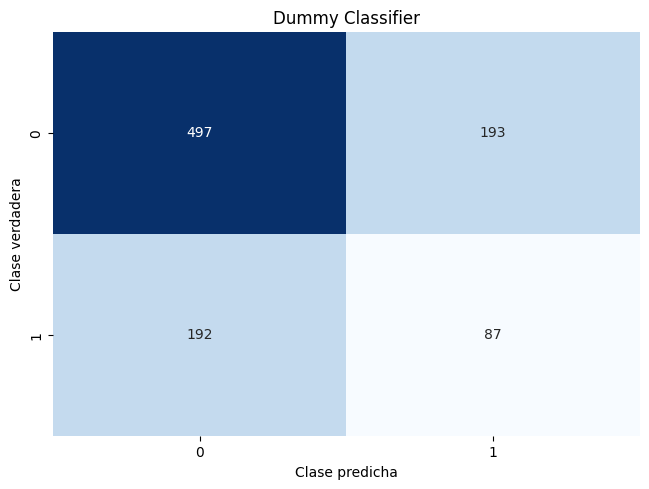

In [8]:
dummy = DummyClassifier(strategy='stratified', random_state=SEED)

dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
y_proba_dummy = dummy.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_dummy, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_dummy):.3f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_proba_dummy):.3f}")

plot_confusion_matrix(y_test, y_pred_dummy, "Dummy Classifier")

resultados_modelos['Dummy'] = {
    'roc_auc': roc_auc_score(y_test, y_proba_dummy),
    'pr_auc': average_precision_score(y_test, y_proba_dummy),
    'y_pred': y_pred_dummy,
    'y_proba': y_proba_dummy,
}

>ROC-AUC=0.516 y PR-AUC=0.295, casi idéntico a la proporción real de positivos. Se confirma que el Dummy no aporta ninguna capacidad predictiva real, tal
como se espera. A partir de este punto, esta debe de ser la referencia y cualquier modelo con PR-AUC por debajo de aproximadamente 0.30
no estaría aportando nada a la predicción.

### 6.2) Regresión Logística

Se ajusta mediante `GridSearchCV` sobre el hiperparámetro de regularización `C`. Se comienza con el siguiente rango de valores de `C` posibles: [0.01, 0.1, 1, 10], pero en el caso de que se obtenga como mejor hiperparámetro un valor extremo, se modificará el array con valores más proximos a él. Se usa la `cv` común definida antes de la Sección 6.1, y `scoring='average_precision'` para la optimización.

In [9]:
lr = Pipeline([
    ('prep', preprocessor_lr),
    ('lr', LogisticRegression(max_iter=1000, random_state=SEED))
])

param_grid_lr = {
    'lr__C': [0.01, 0.1, 1, 10, 50, 100]
}

grid_lr = GridSearchCV(lr, param_grid_lr, scoring='average_precision', cv=cv, n_jobs=-1)

grid_lr.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_lr.best_params_)
print(f"Mejor PR-AUC en CV: {grid_lr.best_score_:.4f}")

Mejores hiperparámetros: {'lr__C': 10}
Mejor PR-AUC en CV: 0.5417


Accuracy: 0.735
F1-score: 0.356
Recall: 0.254
Precision: 0.592
ROC-AUC: 0.736
PR-AUC: 0.518


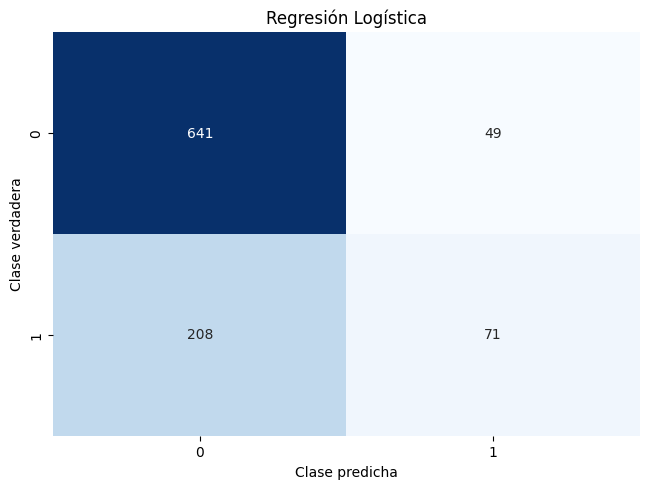

In [10]:
best_lr = grid_lr.best_estimator_

y_pred_test_lr = best_lr.predict(X_test)
y_proba_test_lr = best_lr.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_test_lr):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred_test_lr):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_test_lr):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_test_lr):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_test_lr):.3f}")
print(f"PR-AUC: {average_precision_score(y_test, y_proba_test_lr):.3f}")

plot_confusion_matrix(y_test, y_pred_test_lr, "Regresión Logística")

resultados_modelos['Regresión Logística'] = {
    'roc_auc': roc_auc_score(y_test, y_proba_test_lr),
    'pr_auc': average_precision_score(y_test, y_proba_test_lr),
    'y_pred': y_pred_test_lr,
    'y_proba': y_proba_test_lr,
}

### 6.3) Random Forest

Se ajusta mediante `GridSearchCV` sobre `n_estimators`, `max_depth` y `min_samples_leaf`, con la misma `cv` y `scoring='average_precision'` que en Regresión Logística. Se usa `preprocessor_rf` (imputación `"Unknown"` + one-hot, sin escalado, ya que los árboles no lo necesitan).

In [11]:
rf = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('rf', RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

param_grid_rf = {
    'rf__n_estimators': [200, 400, 600],
    'rf__max_depth': [3, 5, 10],
    'rf__min_samples_leaf': [1, 5, 10],
    'rf__min_samples_split': [3, 5, 7],
}

grid_rf = GridSearchCV(rf, param_grid_rf, scoring='average_precision', cv=cv, n_jobs=-1)

grid_rf.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_rf.best_params_)
print(f"Mejor PR-AUC en CV: {grid_rf.best_score_:.4f}")

Mejores hiperparámetros: {'rf__max_depth': 5, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 400}
Mejor PR-AUC en CV: 0.5480


Accuracy:  0.733
F1-score:  0.162
Recall:    0.090
Precision: 0.833
ROC-AUC:   0.737
PR-AUC:    0.559


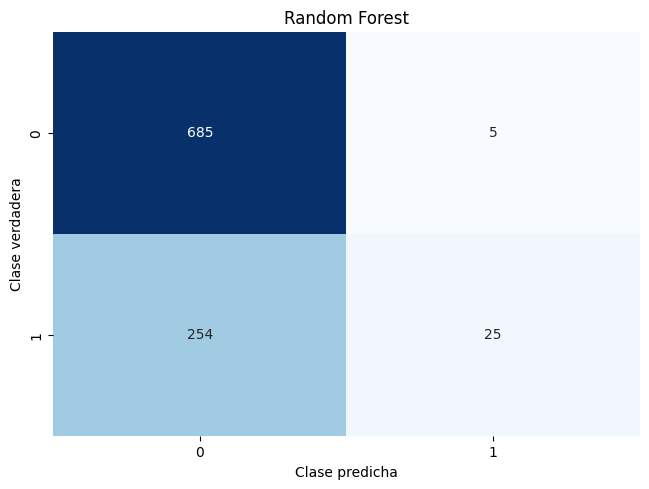

In [12]:
best_rf = grid_rf.best_estimator_
y_pred_test_rf = best_rf.predict(X_test)
y_proba_test_rf = best_rf.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_test_rf):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred_test_rf):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_test_rf):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_test_rf):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_test_rf):.3f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_proba_test_rf):.3f}")

plot_confusion_matrix(y_test, y_pred_test_rf, "Random Forest")

resultados_modelos['Random Forest'] = {
    'roc_auc': roc_auc_score(y_test, y_proba_test_rf),
    'pr_auc': average_precision_score(y_test, y_proba_test_rf),
    'y_pred': y_pred_test_rf,
    'y_proba': y_proba_test_rf,
}

### 6.4) XGBoost

Se ajusta mediante `GridSearchCV` sobre `max_depth`, `learning_rate`, `n_estimators` y `subsample`, sin `ColumnTransformer`. Com se comentó, XGBoost gestiona los `NaN` y las columnas categóricas de pandas.

In [13]:
xgb = XGBClassifier(random_state=SEED, enable_categorical=True, tree_method='hist', eval_metric='aucpr')

param_grid_xgb = {
    'max_depth': [2, 3, 4],
    'learning_rate': [0.005, 0.01, 0.02, 0.03],
    'n_estimators': [400, 600, 800],
    'subsample': [0.8],
}

grid_xgb = GridSearchCV(xgb, param_grid_xgb, scoring='average_precision', cv=cv, n_jobs=-1)
grid_xgb.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_xgb.best_params_)
print(f"Mejor PR-AUC en CV: {grid_xgb.best_score_:.4f}")

Mejores hiperparámetros: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 600, 'subsample': 0.8}
Mejor PR-AUC en CV: 0.5502


Accuracy:  0.745
F1-score:  0.387
Recall:    0.280
Precision: 0.629
ROC-AUC:   0.745
PR-AUC:    0.561


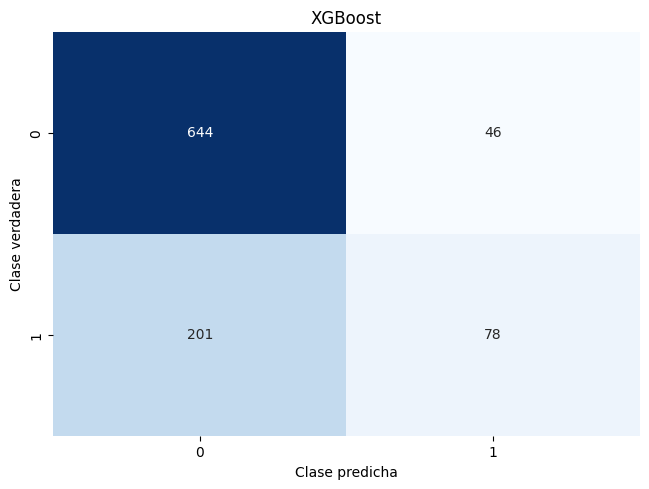

In [14]:
best_xgb = grid_xgb.best_estimator_
y_pred_test_xgb = best_xgb.predict(X_test)
y_proba_test_xgb = best_xgb.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_test_xgb):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred_test_xgb):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_test_xgb):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_test_xgb):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_test_xgb):.3f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_proba_test_xgb):.3f}")

plot_confusion_matrix(y_test, y_pred_test_xgb, "XGBoost")

resultados_modelos['XGBoost'] = {
    'roc_auc': roc_auc_score(y_test, y_proba_test_xgb),
    'pr_auc': average_precision_score(y_test, y_proba_test_xgb),
    'y_pred': y_pred_test_xgb,
    'y_proba': y_proba_test_xgb,
}

### 6.5) Comparación de los modelos

Se construye una tabla resumen a partir de `resultados_modelos`, con las métricas de test de los 4 modelos evaluadas con las mismas condiciones.

In [15]:
comparacion = []
for nombre, res in resultados_modelos.items():
    comparacion.append({
        'Modelo': nombre,
        'PR-AUC': res['pr_auc'],
        'ROC-AUC': res['roc_auc'],
        'Accuracy': accuracy_score(y_test, res['y_pred']),
        'F1': f1_score(y_test, res['y_pred']),
        'Recall': recall_score(y_test, res['y_pred']),
        'Precision': precision_score(y_test, res['y_pred']),
    })

df_comparacion = pd.DataFrame(comparacion).sort_values('PR-AUC', ascending=False).reset_index(drop=True)
df_comparacion.round(3)

,Modelo,PR-AUC,ROC-AUC,Accuracy,F1,Recall,Precision
0,XGBoost,0.561,0.745,0.745,0.387,0.280,0.629
1,Random Forest,0.559,0.737,0.733,0.162,0.090,0.833
2,Regresión Logística,0.518,0.736,0.735,0.356,0.254,0.592
3,Dummy,0.295,0.516,0.603,0.311,0.312,0.311


Como se puede observar, los tres modelos reales superan claramente a Dummy en PR-AUC/ROC-AUC (XGBoost +89% de PR-AUC sobre Dummy), confirmando que las features aportan señal
real. RF y XGBoost tienen un PR-AUC muy similar (0.559 y 0.561), pero con comportamientos opuestos con el umbral 0.5: Random Forest es extremadamente conservador (precision=0.833, recall=0.090), mientras que XGBoost logra el mejor equilibrio de los cuatro (F1=0.387).

Llama la atención que el recall de Dummy (0.312) sea el más alto de la tabla, pero esto no es destacable, ya que al predecir al azar según la proporción de clases, su recall es siempre cercano a esa proporción (28.8%) por pura estadística, el modelo no predice nada. El PR-AUC confirma que XGBoost ordena a los pacientes muchísimo mejor que Dummy, siendo el recall actual todavía bajo en consecuencia de un umbral (0.5) no calibrado, no una limitación real del modelo. 

Por tanto, se selecciona **XGBoost** como modelo final. Este se va a calibrar en la siguiente sección, donde se espera que el recall, una de las métricas más importantes de este problema, mejore sustancialmente.

### 6.6) Optimización del modelo XGBoost

Se busca mejorar el rendimiento de XGBoost desde dos frentes: el umbral de decisión y el conjunto de variables. Los resultados de la Sección 6.5 usan el umbral por defecto (0 5), no calibrado, y se explora si la variable *tumor_size_cs* puede aportar señal.

#### Barrido de umbral y de β

Se calculan las predicciones mediante `cross_val_predict` sobre `X_train`, y se evalúa cómo cambian el umbral óptimo y las métricas al variar β, que es el peso
del recall frente a la precisión en la métrica F-beta.

In [16]:
y_proba_cv = cross_val_predict(best_xgb, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
thresholds = np.arange(0.01, 0.95, 0.01)

betas = [1, 1.25, 1.5, 1.75, 2, 3, 5]
rows = []
for beta in betas:
    scores = [fbeta_score(y_train, (y_proba_cv >= t).astype(int), beta=beta, zero_division=0) for t in thresholds]
    best_idx = np.argmax(scores)
    best_t = thresholds[best_idx]
    pred = (y_proba_cv >= best_t).astype(int)
    rows.append({
        'Beta': beta,
        'Umbral óptimo': round(best_t, 3),
        'F-beta': round(scores[best_idx], 3),
        'Precision': round(precision_score(y_train, pred, zero_division=0), 3),
        'Recall': round(recall_score(y_train, pred, zero_division=0), 3),
        '% marcados positivo': round(pred.mean() * 100, 1),
    })

tabla_beta = pd.DataFrame(rows)
tabla_beta

,Beta,Umbral óptimo,F-beta,Precision,Recall,% marcados positivo
0,1.00,0.30,0.543,0.470,0.644,39.4
1,1.25,0.20,0.575,0.385,0.838,62.6
2,1.50,0.18,0.616,0.371,0.872,67.5
3,1.75,0.14,0.656,0.343,0.934,78.4
4,2.00,0.12,0.696,0.332,0.958,83.0
5,3.00,0.10,0.811,0.324,0.974,86.5
6,5.00,0.03,0.913,0.290,0.999,99.1


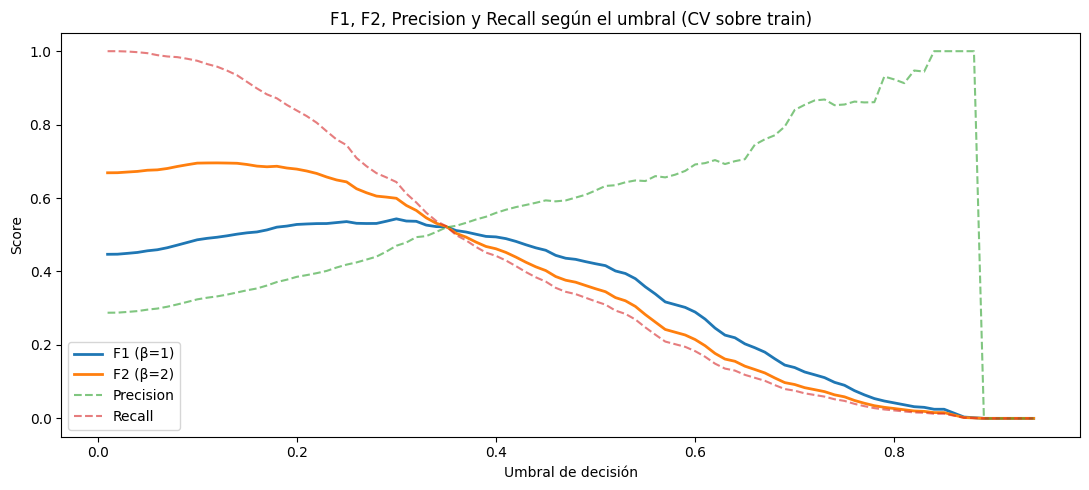

In [17]:
f1_scores = [fbeta_score(y_train, (y_proba_cv >= t).astype(int), beta=1, zero_division=0) for t in thresholds]
f2_scores = [fbeta_score(y_train, (y_proba_cv >= t).astype(int), beta=2, zero_division=0) for t in thresholds]
precisions = [precision_score(y_train, (y_proba_cv >= t).astype(int), zero_division=0) for t in thresholds]
recalls = [recall_score(y_train, (y_proba_cv >= t).astype(int), zero_division=0) for t in thresholds]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds, f1_scores, label='F1 (β=1)', linewidth=2)
ax.plot(thresholds, f2_scores, label='F2 (β=2)', linewidth=2)
ax.plot(thresholds, precisions, label='Precision', linestyle='--', alpha=0.6)
ax.plot(thresholds, recalls, label='Recall', linestyle='--', alpha=0.6)
ax.set_xlabel('Umbral de decisión')
ax.set_ylabel('Score')
ax.legend()
ax.set_title('F1, F2, Precision y Recall según el umbral (CV sobre train)')
plt.tight_layout()
plt.show()

Aumentar β desplaza el umbral óptimo hacia valores más bajos y sube el recall. A partir de β≥1.75 los umbrales óptimos ya son muy bajos (0.10-0.14) y el recall se acerca al máximo posible (0.93-0.98), mientras que a partir de β≥3 el sistema empeora y marca a casi todos los pacientes como alto riesgo (88.6%-99.1%), perdiendo gran capacidad de discriminación.

**`Se adopta β=1.5, umbral=0.18`**: equilibrio entre priorizar el recall (0.872, coherente con el coste clínico de un falso negativo) y mantener un sistema que aún estratifica de forma útil, marcando al 67.5% de los pacientes en vez de acercarse al 100%.

#### Variables adicionales: `tumor_size_cs`

Se prueba añadir `tumor_size_cs` (excluida hasta ahora por 61.1% de missing) de dos formas: directamente sobre el dataset completo (XGBoost tolera el `NaN` nativo), y restringiendo a los años 2004-2015, donde la variable sí está mayoritariamente disponible por características del dataset.

In [18]:
# Se añade tumor_size_cs a la lista de features
feature_cols_con_tumor_size = feature_cols + ['tumor_size_cs']

X_con_tumor_size = df[feature_cols_con_tumor_size]

X_train_ts, X_test_ts, y_train_ts, y_test_ts = train_test_split(X_con_tumor_size, y, test_size=0.2, stratify=y, random_state=SEED)

# XGBoost con los hiperparámetros encontrados en la Sección 6.4
xgb_con_tumor_size = XGBClassifier(
    random_state=SEED, enable_categorical=True, tree_method='hist', eval_metric='aucpr',
    max_depth=3, learning_rate=0.01, n_estimators=600, subsample=0.8
)

xgb_con_tumor_size.fit(X_train_ts, y_train_ts)

proba_con_tumor_size = xgb_con_tumor_size.predict_proba(X_test_ts)[:, 1]

print(f"Dataset completo sin tumor_size_cs: PR-AUC=0.562, ROC-AUC=0.745")
print(f"Dataset completo con tumor_size_cs: PR-AUC={average_precision_score(y_test_ts, proba_con_tumor_size):.3f}, "
      f"ROC-AUC={roc_auc_score(y_test_ts, proba_con_tumor_size):.3f}")


# Subconjunto de pacientes diagnosticados entre 2004 y 2015
df_2004_2015 = df[(df['year_diagnosis'] >= 2004) & (df['year_diagnosis'] <= 2015)].copy()
y_2004_2015 = df_2004_2015['target']

print(f"\nPacientes en 2004-2015: {len(df_2004_2015)}")
print(f"% missing de tumor_size_cs en este subconjunto: {df_2004_2015['tumor_size_cs'].isnull().mean()*100:.1f}%")


# Subconjunto 2004-2015 sin tumor_size_cs
X_2004_2015_sin_ts = df_2004_2015[feature_cols]

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_2004_2015_sin_ts, y_2004_2015, test_size=0.2, stratify=y_2004_2015, random_state=SEED)

xgb_sin_ts = XGBClassifier(
    random_state=SEED, enable_categorical=True, tree_method='hist', eval_metric='aucpr',
    max_depth=3, learning_rate=0.01, n_estimators=600, subsample=0.8
)

xgb_sin_ts.fit(X_train_a, y_train_a)

proba_sin_ts = xgb_sin_ts.predict_proba(X_test_a)[:, 1]

# Subconjunto 2004-2015 con tumor_size_cs
X_2004_2015_con_ts = df_2004_2015[feature_cols_con_tumor_size]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_2004_2015_con_ts, y_2004_2015, test_size=0.2, stratify=y_2004_2015, random_state=SEED)

xgb_con_ts = XGBClassifier(
    random_state=SEED, enable_categorical=True, tree_method='hist', eval_metric='aucpr',
    max_depth=3, learning_rate=0.01, n_estimators=600, subsample=0.8
)

xgb_con_ts.fit(X_train_b, y_train_b)

proba_con_ts = xgb_con_ts.predict_proba(X_test_b)[:, 1]

print(f"\nSubconjunto 2004-2015:")
print(f"Sin tumor_size_cs: PR-AUC={average_precision_score(y_test_a, proba_sin_ts):.3f}, "
      f"ROC-AUC={roc_auc_score(y_test_a, proba_sin_ts):.3f}")
print(f"Con tumor_size_cs: PR-AUC={average_precision_score(y_test_b, proba_con_ts):.3f}, "
      f"ROC-AUC={roc_auc_score(y_test_b, proba_con_ts):.3f}")


Dataset completo sin tumor_size_cs: PR-AUC=0.562, ROC-AUC=0.745
Dataset completo con tumor_size_cs: PR-AUC=0.554, ROC-AUC=0.743

Pacientes en 2004-2015: 2457
% missing de tumor_size_cs en este subconjunto: 22.3%

Subconjunto 2004-2015:
Sin tumor_size_cs: PR-AUC=0.628, ROC-AUC=0.753
Con tumor_size_cs: PR-AUC=0.631, ROC-AUC=0.759


Si se compara directamente el resultado del dataset completo PR-AUC=0.562 contra el del subconjunto 2004-2015 con tumor_size_cs PR-AUC=0.631, parece una mejora reseñable (+0.069). Pero esa comparación mezcla dos efectos distintos, ya que la mejora sustancial ya ocurre solo por restringir a 2004-2015 sin llegar a añadir la variable (PR-AUC=0.628, +0.063). Debido probablemente a menos missing en otras variables en ese periodo. El efecto real y aislado de `tumor_size_cs`, comparando el mismo subconjunto con y sin ella, es mucho menor, +0.003 en PR-AUC.

Además, adoptar el modelo restringido a 2004-2015 como modelo principal es menos viable en la práctica, dado que el sistema debe predecir sobre pacientes diagnosticados en cualquier momento, incluidos los más recientes. Un modelo limitado a esa ventana no podría usarse con ellos y justo el caso de uso más relevante de una herramienta de apoyo clínico.

Por tanto, **se descarta `tumor_size_cs` del modelo principal**. Su efecto real aislado es pequeño (+0.003) y restringir la cobertura temporal contradice el propósito del sistema.

### 6.7) Aplicación del umbral final sobre test

Se aplica el umbral 0.18 (β=1.5) una única vez sobre `X_test`, con el modelo XGBoost ya entrenado, cerrando así la fase de optimización del modelo.

Accuracy:  0.540
F1-score:  0.522
Recall:    0.875
Precision: 0.373
ROC-AUC:   0.745
PR-AUC:    0.561


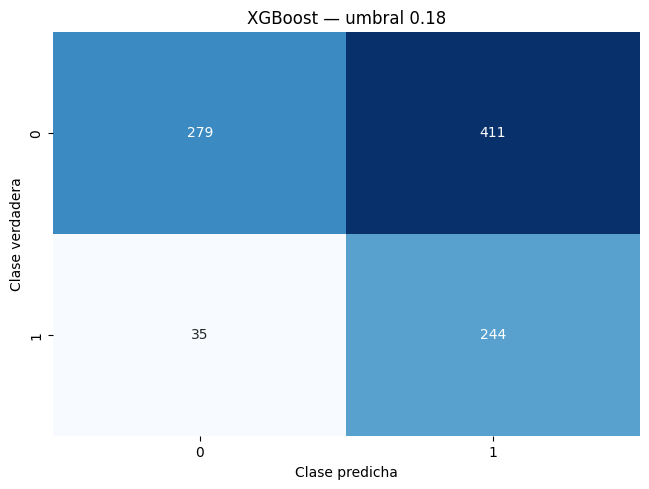

In [19]:
THRESHOLD_FINAL = 0.18
y_pred_test_final = (y_proba_test_xgb >= THRESHOLD_FINAL).astype(int)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_test_final):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred_test_final):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_test_final):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_test_final):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_test_xgb):.3f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_proba_test_xgb):.3f}")

plot_confusion_matrix(y_test, y_pred_test_final, f"XGBoost — umbral {THRESHOLD_FINAL}")

resultados_modelos['XGBoost (umbral óptimo)'] = {
    'roc_auc': roc_auc_score(y_test, y_proba_test_xgb),
    'pr_auc': average_precision_score(y_test, y_proba_test_xgb),
    'y_pred': y_pred_test_final,
    'y_proba': y_proba_test_xgb,
}

## 7) Comparación final de modelos

Se actualiza la tabla comparativa de la Sección 6.5, incluyendo el XGBoost con el umbral ya calibrado junto a los 4 modelos originales evaluados con umbral por defecto (0.5).

In [20]:
comparacion_final = []
for nombre, res in resultados_modelos.items():
    y_pred_res = res['y_pred']
    comparacion_final.append({
        'Modelo': nombre,
        'ROC-AUC': res['roc_auc'],
        'PR-AUC': res['pr_auc'],
        'Accuracy': accuracy_score(y_test, y_pred_res),
        'F1': f1_score(y_test, y_pred_res),
        'Recall': recall_score(y_test, y_pred_res),
        'Precision': precision_score(y_test, y_pred_res),
    })

df_comparacion_final = pd.DataFrame(comparacion_final).sort_values('PR-AUC', ascending=False).reset_index(drop=True)
df_comparacion_final.round(3)

,Modelo,ROC-AUC,PR-AUC,Accuracy,F1,Recall,Precision
0,XGBoost (umbral óptimo),0.745,0.561,0.540,0.522,0.875,0.373
1,XGBoost,0.745,0.561,0.745,0.387,0.280,0.629
2,Random Forest,0.737,0.559,0.733,0.162,0.090,0.833
3,Regresión Logística,0.736,0.518,0.735,0.356,0.254,0.592
4,Dummy,0.516,0.295,0.603,0.311,0.312,0.311


Como se puede observar, el XGBoost con umbral calibrado mantiene el mismo PR-AUC/ROC-AUC que con umbral inicial ya que estas métricas no dependen del punto de corte. Pero se cumple con el objetivo de transformar completamente su utilidad clínica, ya que el recall pasa de 0.280 a 0.875, siendo ahora el modelo con mejor recall de toda la comparación, muy por encima incluso del recall aparente de Dummy (0.312) que discutimos anteriormente como no comparable. Analizando todas las posibilidades, este es el modelo definitivo del trabajo.

## 8) Interpretabilidad con SHAP

Se calculan los valores SHAP sobre el modelo XGBoost final, que cuantifican la importancia de cada variable a la predicción de cada paciente individual.

In [21]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

### Summary plot

Por defecto, SHAP colorea cada punto según el valor de la feature, pero solo para variables numéricas. Con las variables categóricas de pandas no sabe mapear los colores, asi que para solucionarlo sin reentrenar nada, se genera una copia de `X_test` únicamente para la visualización con las categorías convertidas a códigos numéricos (`.cat.codes`). Esto no cambia los resultados que saldrían, ya que los valores SHAP en sí no cambian, solo lo que se usa para intepretar de mejor manera el gráfico gracias al color.

C:\Users\alonsocastanon\AppData\Local\Temp\ipykernel_24444\395983022.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_display, show=False)


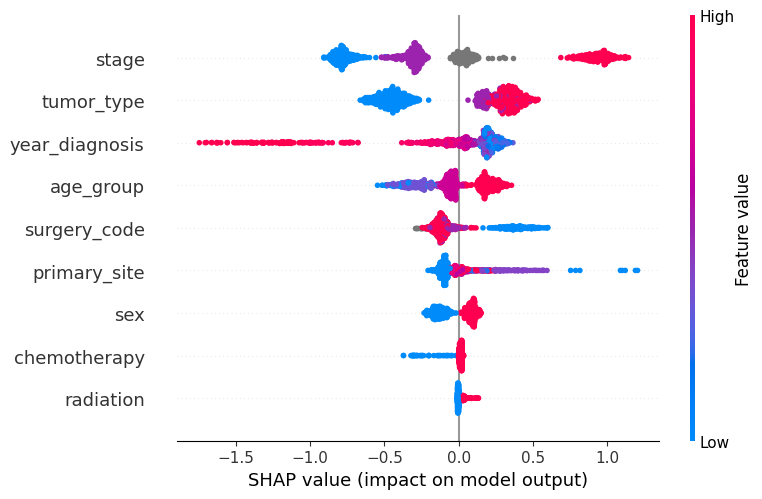

In [22]:
# Copia para la visualización con categorías en numeros
X_test_display = X_test.copy()
for col in X_test_display.select_dtypes(include='category').columns:
    X_test_display[col] = X_test_display[col].cat.codes.replace(-1, float('nan'))

shap.summary_plot(shap_values, X_test_display, show=False)
plt.tight_layout()
plt.show()

> El color en este caso solo tiene un significado interpretable real en las variables ordinales `stage` y `age_group`, donde el código numérico sigue su orden clínico natural. En el resto de variables (`sex`, `tumor_type`, `primary_site`, `surgery_code`, `radiation`, `chemotherapy`) el código es arbitrario y el color solo ayuda a ver que hay grupos diferenciados no una categoría mejor o peor. Para conocer eso, se usan los boxplots por categoría a continuación, que sí son interpretables sin ambigüedad.

### SHAP por categoría (variables más importantes)

Al ser variables categóricas, en vez del `dependence_plot` estándar de SHAP, se usa un boxplot de los valores SHAP agrupados por categoría, ya que es más legible para este tipo de datos.

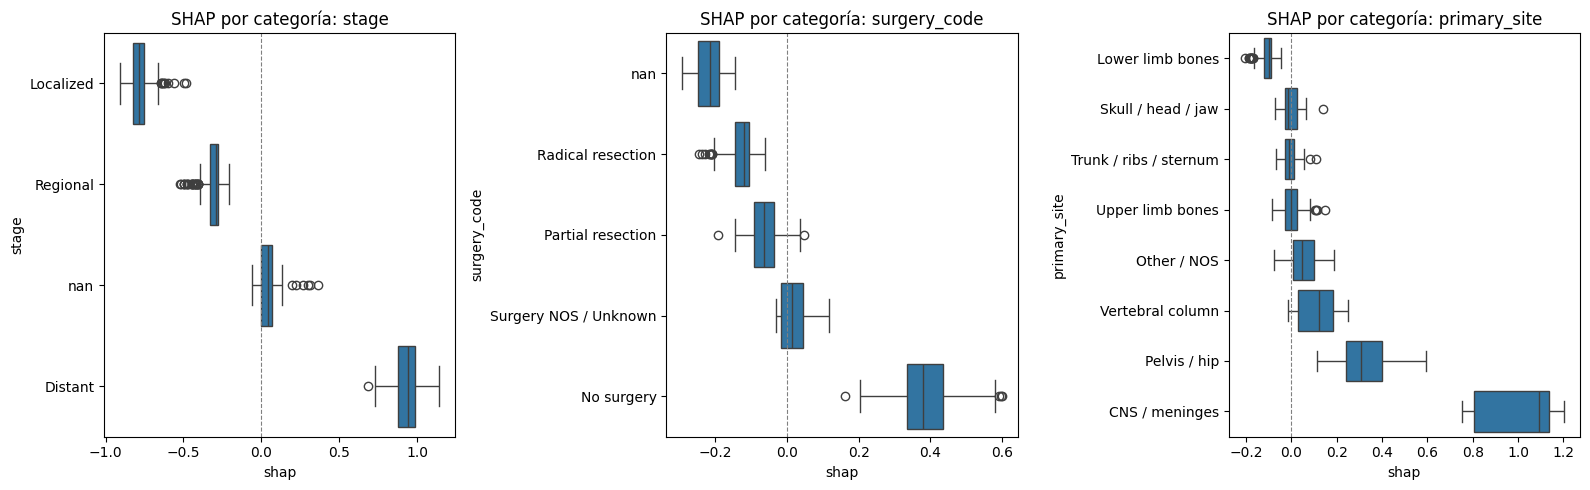

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['stage', 'surgery_code', 'primary_site']):
    idx = feature_cols.index(col)
    tmp = pd.DataFrame({col: X_test[col].astype(str).fillna('NaN').values, 'shap': shap_values[:, idx]})
    order = tmp.groupby(col)['shap'].median().sort_values().index
    sns.boxplot(data=tmp, x='shap', y=col, order=order, ax=ax)
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
    ax.set_title(f'SHAP por categoría: {col}')
plt.tight_layout()
plt.show()

### Comportamiento de los casos con `stage` ausente

Se revisa específicamente cómo trata el modelo los casos de test con `stage=NaN` (nativo, sin imputar), tal como quedó pendiente en la Sección 9 del EDA.

In [24]:
mask_nan = X_test['stage'].isnull()
idx_stage = feature_cols.index('stage')

print(f"Casos con stage=NaN en test: {mask_nan.sum()}")
print(f"SHAP medio (stage=NaN):      {shap_values[mask_nan.values, idx_stage].mean():.3f} (std={shap_values[mask_nan.values, idx_stage].std():.3f})")
print(f"SHAP medio (stage conocido): {shap_values[~mask_nan.values, idx_stage].mean():.3f} (std={shap_values[~mask_nan.values, idx_stage].std():.3f})")

Casos con stage=NaN en test: 189
SHAP medio (stage=NaN):      0.044 (std=0.061)
SHAP medio (stage conocido): -0.130 (std=0.695)


### Interpretación de los resultados SHAP

**Summary plot:** 

Como se puede observar, `stage` es con claridad la variable con mayor impacto. En azul se colorea `Localized`, que empuja fuerte hacia menor riesgo, mientras en rojo está `Distant`, implicando mayor riesgo, lo cual es coherente con todo lo visto en el EDA. `tumor_type` es la segunda en impacto, diferenciándose bien dos grupos. En `year_diagnosis` los años recientes (rojo) empujan hacia menor riesgo, mientras los antiguos (azul) hacia mayor riesgo, que es coherente con la mejora de tratamientos oncológicos en el tiempo.  El resto de variables tienen impacto bajo, coherente con el bivariante del EDA.

**Boxplots por categoría:**

- **`stage`**: separación clara y ordenada (`Localized` < `Regional` < `Distant`), lo que confirma visualmente por qué es la variable dominante del modelo.
- **`surgery_code`**: `No surgery` empuja claramente hacia mayor riesgo, `Radical resection` hacia menor riesgo, coherente con la realidad clínica. Los casos con `surgery_code` ausente (los 210 pacientes de 2023 sin dato por el propio diseño de la variable SEER, ver Sección 6 del EDA) muestran el SHAP más negativo del grupo.
- **`primary_site`**: `CNS/meninges` tiene, con diferencia, el SHAP más alto y una caja relativamente estrecha pese a ser la categoría con menos casos. Esto confirma el hallazgo del EDA (Sección 5) sobre su pronóstico, y valida la decisión de mantenerla sin agrupar con `Other/NOS`, ya que la señal es fuerte y estable.

**Comportamiento con `stage` ausente:** 

Los 189 casos de test con `stage=NaN` reciben una contribución SHAP pequeña y positiva (0.044), con muy poca variabilidad (std=0.061 frente a 0.695 en los casos con `stage` conocido). El modelo trata el missing de forma estable y consistente, sin comportamiento errático y confirma que dejar `stage` como `NaN` fue la decisión adecuada.

## 9) Guardado del modelo

Se serializa el modelo final y se guardan los splits de train/test para reproducibilidad.

In [25]:
cat_model_vars

['age_group',
 'sex',
 'tumor_type',
 'primary_site',
 'stage',
 'surgery_code',
 'radiation',
 'chemotherapy']

In [26]:
num_model_vars

['year_diagnosis']

In [27]:
esquema_categorias = {
    col: list(X_train[col].cat.categories) for col in cat_model_vars
}

esquema_numericas = {
    col: {'min': int(X_train[col].min()), 'max': int(X_train[col].max())} for col in num_model_vars
}

esquema_completo = {
    'categoricas': esquema_categorias,
    'numericas': esquema_numericas,
}

with open('../models/esquema_categorias.json', 'w', encoding='utf-8') as f:
    json.dump(esquema_completo, f, ensure_ascii=False, indent=2)

print("Esquema guardado:")
print(json.dumps(esquema_completo, ensure_ascii=False, indent=2))

os.makedirs('../models', exist_ok=True)

with open('../models/xgboost_final.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)

print("Modelo guardado en ../models/xgboost_final.pkl")

os.makedirs('../data/splits', exist_ok=True)

X_train.assign(target=y_train).to_csv('../data/splits/train.csv', index=False)
X_test.assign(target=y_test).to_csv('../data/splits/test.csv', index=False)

print(f"Train guardado: {X_train.shape[0]} filas")
print(f"Test guardado: {X_test.shape[0]} filas")

Esquema guardado:
{
  "categoricas": {
    "age_group": [
      "00 years",
      "01-04 years",
      "05-09 years",
      "10-14 years",
      "15-19 years"
    ],
    "sex": [
      "Female",
      "Male"
    ],
    "tumor_type": [
      "Ewing sarcoma",
      "Osteosarcoma (other subtypes)",
      "Osteosarcoma NOS"
    ],
    "primary_site": [
      "CNS / meninges",
      "Lower limb bones",
      "Other / NOS",
      "Pelvis / hip",
      "Skull / head / jaw",
      "Trunk / ribs / sternum",
      "Upper limb bones",
      "Vertebral column"
    ],
    "stage": [
      "Localized",
      "Regional",
      "Distant"
    ],
    "surgery_code": [
      "No surgery",
      "Partial resection",
      "Radical resection",
      "Surgery NOS / Unknown"
    ],
    "radiation": [
      "No radiation",
      "Radiation",
      "Recommended / Unknown",
      "Refused"
    ],
    "chemotherapy": [
      "No/Unknown",
      "Yes"
    ]
  },
  "numericas": {
    "year_diagnosis": {
      "min

### Resumen del notebook

Se entrenaron y compararon 4 modelos (Dummy, Regresión Logística, Random Forest, XGBoost) para predecir la no supervivencia a 5 años en osteosarcoma y Ewing pediátrico. **XGBoost** se selecciona como modelo final, ya que, como se ha observado, es el que proporciona mejor equilibrio de métricas (PR-AUC=0.561, ROC-AUC=0.745), tolera de forma nativa el missing estructural y las variables categóricas de alta cardinalidad, y es compatible con SHAP para la interpretabilidad clínica requerida.

El umbral de decisión por defecto (0.5) daba lugar a un recall muy bajo (0.280), que resulta inadecuado dado el coste clínico de un falso negativo. Tras un barrido de umbral y de β, se adopta **β=1.5, umbral=0.18**, elevando el recall a 0.875 con una pérdida de precisión asumible (0.373). Se descarta incluir `tumor_size_cs`, ya que su efecto real aislado es mínimo y reduce la cobertura temporal del modelo.

Con SHAP se confirma `stage` como el factor pronóstico más importante, seguido de `tumor_type` y `year_diagnosis`, coherente con todos los análisis del EDA. Se valida la decisión de mantener `CNS/meninges` sin agrupar y de tratar `stage` como `NaN` nativo.

**Limitaciones encontradas:** 

SEER Research Data es un registro poblacional, no un registro clínico detallado. Recoge el estado, tratamiento a alto nivel y desenlace, pero carece de variables que en la práctica clínica pesan mucho sobre el pronóstico y con las que sería genial contar, como la respuesta histológica a la quimioterapia, márgenes quirúrgicos, marcadores moleculares y genómicos del tumor o comorbilidades del paciente. El modelo solo puede aprender de la información con la que se cuenta, y ese techo de información limita el rendimiento máximo que puede alcanzar, independientemente del algoritmo usado. No obstante, se desarrollarán más detalladamente estas y otras limitaciones en las conclusiones del proyecto.